In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:

df = pd.read_csv("/content/sample_data/Indian Liver Patient Dataset (ILPD).csv")
print(df.head())


   Age  Gender    TB   DB  Alkphos  Sgpt  Sopt   TP  ALB  A/G Ratio  Selector
0   65  Female   0.7  0.1      187    16    18  6.8  3.3       0.90         1
1   62    Male  10.9  5.5      699    64   100  7.5  3.2       0.74         1
2   62    Male   7.3  4.1      490    60    68  7.0  3.3       0.89         1
3   58    Male   1.0  0.4      182    14    20  6.8  3.4       1.00         1
4   72    Male   3.9  2.0      195    27    59  7.3  2.4       0.40         1


In [3]:
print(df.isnull().sum())

df.fillna(df.mean(numeric_only=True), inplace=True)

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

df['Selector'] = df['Selector'].replace({1:1, 2:0})

print("\nAfter Cleaning:")
print(df.head())


Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sopt         0
TP           0
ALB          0
A/G Ratio    4
Selector     0
dtype: int64

After Cleaning:
   Age  Gender    TB   DB  Alkphos  Sgpt  Sopt   TP  ALB  A/G Ratio  Selector
0   65       0   0.7  0.1      187    16    18  6.8  3.3       0.90         1
1   62       1  10.9  5.5      699    64   100  7.5  3.2       0.74         1
2   62       1   7.3  4.1      490    60    68  7.0  3.3       0.89         1
3   58       1   1.0  0.4      182    14    20  6.8  3.4       1.00         1
4   72       1   3.9  2.0      195    27    59  7.3  2.4       0.40         1


In [6]:
print(df.describe())
print(df.corr())


              Age      Gender          TB          DB      Alkphos  \
count  583.000000  583.000000  583.000000  583.000000   583.000000   
mean    44.746141    0.756432    3.298799    1.486106   290.576329   
std     16.189833    0.429603    6.209522    2.808498   242.937989   
min      4.000000    0.000000    0.400000    0.100000    63.000000   
25%     33.000000    1.000000    0.800000    0.200000   175.500000   
50%     45.000000    1.000000    1.000000    0.300000   208.000000   
75%     58.000000    1.000000    2.600000    1.300000   298.000000   
max     90.000000    1.000000   75.000000   19.700000  2110.000000   

              Sgpt         Sopt          TP         ALB   A/G Ratio  \
count   583.000000   583.000000  583.000000  583.000000  583.000000   
mean     80.713551   109.910806    6.483190    3.141852    0.947064   
std     182.620356   288.918529    1.085451    0.795519    0.318492   
min      10.000000    10.000000    2.700000    0.900000    0.300000   
25%      23.00

In [7]:
X = df.drop('Selector', axis=1)
y = df['Selector']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)


Training Size: (466, 10)
Testing Size: (117, 10)


In [10]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)



LogisticRegression(max_iter=1000)

In [14]:
y_pred = model.predict(X_test)
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nTesting Results (Actual vs Predicted):")
print(results.head(20))



Testing Results (Actual vs Predicted):
    Actual  Predicted
0        0          0
1        1          1
2        1          1
3        1          1
4        1          1
5        1          1
6        0          0
7        0          1
8        0          0
9        1          1
10       0          1
11       1          1
12       0          1
13       1          1
14       1          1
15       1          1
16       1          1
17       1          1
18       1          1
19       1          1


Testing Accuracy: 0.7606837606837606


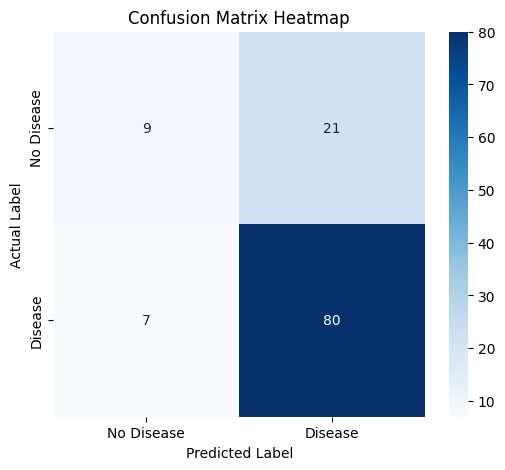


Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.30      0.39        30
           1       0.79      0.92      0.85        87

    accuracy                           0.76       117
   macro avg       0.68      0.61      0.62       117
weighted avg       0.73      0.76      0.73       117



In [18]:

accuracy = accuracy_score(y_test, y_pred)
print("Testing Accuracy:", accuracy)

cm=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


In [19]:
df = pd.read_csv("/content/sample_data/USA_Housing.csv")
print(df.head())


   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09     23086.800503  1.059034e+06   
1                          3.09     40173.072174  1.505891e+06   
2                          5.13     36882.159400  1.058988e+06   
3                          3.26     34310.242831  1.260617e+06   
4                          4.23     26354.109472  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\nLake Kathleen, CA...  
2  9127 Eli

In [21]:
median_price = df['Price'].median()

df['Price_Class'] = np.where(
    df['Price'] >= median_price,
    1,   # High Price
    0    # Low Price
)


In [22]:
df.drop(['Price', 'Address'], axis=1, inplace=True)


In [23]:
X = df.drop('Price_Class', axis=1)
y = df['Price_Class']


In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [26]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [27]:
y_pred = model.predict(X_test)
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nTesting Results (Actual vs Predicted):")
print(results.head(20))



Testing Results (Actual vs Predicted):
    Actual  Predicted
0        1          1
1        1          1
2        1          1
3        1          0
4        0          0
5        1          1
6        1          0
7        0          0
8        0          0
9        1          1
10       0          0
11       1          1
12       0          0
13       1          1
14       1          1
15       0          0
16       1          1
17       0          0
18       0          0
19       0          0


Accuracy: 0.905

Confusion Matrix:


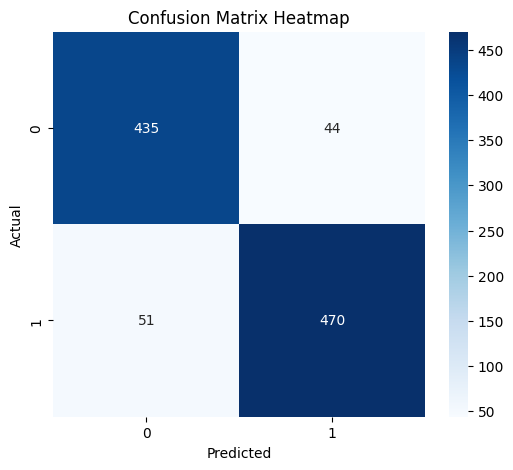


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90       479
           1       0.91      0.90      0.91       521

    accuracy                           0.91      1000
   macro avg       0.90      0.91      0.90      1000
weighted avg       0.91      0.91      0.91      1000



In [29]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
